In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Set styling
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [15]:
class DataCleanerSuite:
    """
    Automated Data Cleaning and Quality Validation Engine.
    """
    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()
        self.audit_log = []

    def _log(self, message: str):
        self.audit_log.append(message)

    def trim_whitespace(self):
        """Trims leading and trailing whitespace from string columns."""
        str_cols = self.df.select_dtypes(include=['object', 'string']).columns
        for col in str_cols:
            self.df[col] = self.df[col].astype(str).str.strip()
        self._log(f"Normalized whitespace across {len(str_cols)} string columns.")
        return self

    def remove_duplicates(self):
        """Deduplicates exact duplicate rows."""
        initial_rows = len(self.df)
        self.df.drop_duplicates(inplace=True)
        dropped = initial_rows - len(self.df)
        self._log(f"Removed {dropped} exact duplicate rows.")
        return self

    def drop_empty_columns(self, threshold=0.9):
        """Drops columns where missing percentage meets or exceeds threshold."""
        empty_cols = [col for col in self.df.columns if self.df[col].isnull().mean() >= threshold]
        if empty_cols:
            self.df.drop(columns=empty_cols, inplace=True)
            self._log(f"Dropped {len(empty_cols)} column(s) with missing rate >= {int(threshold*100)}%: {empty_cols}")
        return self

    def impute_missing(self, num_strategy='median', cat_fill='Missing'):
        """Imputes missing values dynamically across numerical and categorical types."""
        num_cols = self.df.select_dtypes(include=[np.number]).columns
        cat_cols = self.df.select_dtypes(exclude=[np.number]).columns

        for col in num_cols:
            null_count = self.df[col].isnull().sum()
            if null_count > 0:
                fill_val = self.df[col].median() if num_strategy == 'median' else self.df[col].mean()
                self.df[col] = self.df[col].fillna(fill_val)
                self._log(f"Imputed {null_count} missing values in '{col}' using {num_strategy} ({fill_val:.2f}).")

        for col in cat_cols:
            null_count = self.df[col].isnull().sum()
            if null_count > 0:
                self.df[col] = self.df[col].fillna(cat_fill)
                self._log(f"Imputed {null_count} missing values in '{col}' with token '{cat_fill}'.")

        return self

    def cap_outliers_iqr(self, factor=1.5):
        """Caps extreme numerical outliers using lower and upper IQR boundaries."""
        num_cols = self.df.select_dtypes(include=[np.number]).columns
        for col in num_cols:
            q1 = self.df[col].quantile(0.25)
            q3 = self.df[col].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - (factor * iqr)
            upper_bound = q3 + (factor * iqr)
            
            outliers = ((self.df[col] < lower_bound) | (self.df[col] > upper_bound)).sum()
            if outliers > 0:
                self.df[col] = np.clip(self.df[col], lower_bound, upper_bound)
                self._log(f"Capped {outliers} outliers in '{col}' to range [{lower_bound:.2f}, {upper_bound:.2f}].")
        return self

    def export_csv(self, file_path='/kaggle/working/cleaned_dataset.csv'):
        """Exports the cleaned DataFrame directly to a CSV file."""
        self.df.to_csv(file_path, index=False)
        self._log(f"Exported cleaned dataset to {file_path}")
        return self

    def get_audit_report(self):
        """Returns the logged audit actions."""
        return self.audit_log

Raw Dataset Shape: (945, 1149)


<Figure size 1000x400 with 0 Axes>

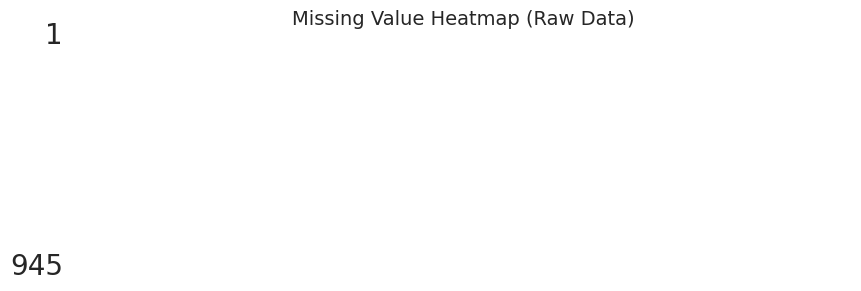


 Pipeline Execution Summary
1. Normalized whitespace across 4 string columns.
2. Removed 0 exact duplicate rows.
3. Dropped 1 column(s) with missing rate >= 90%: ['Unnamed: 122']
4. Imputed 15 missing values in 'education' using median (13.00).
5. Imputed 13 missing values in 'IQ' using median (102.00).
6. Capped 50 outliers in 'age' to range [1.15, 56.03].
7. Capped 7 outliers in 'education' to range [6.00, 22.00].
8. Capped 6 outliers in 'IQ' to range [56.50, 148.50].
9. Capped 48 outliers in 'AB.A.delta.a.FP1' to range [-4.78, 42.05].
10. Capped 47 outliers in 'AB.A.delta.b.FP2' to range [-5.93, 44.61].
11. Capped 48 outliers in 'AB.A.delta.c.F7' to range [-4.60, 37.36].
12. Capped 27 outliers in 'AB.A.delta.d.F3' to range [-3.87, 39.68].
13. Capped 24 outliers in 'AB.A.delta.e.Fz' to range [-4.49, 43.61].
14. Capped 28 outliers in 'AB.A.delta.f.F4' to range [-4.34, 40.94].
15. Capped 38 outliers in 'AB.A.delta.g.F8' to range [-5.26, 36.45].
16. Capped 50 outliers in 'AB.A.delta.h.

In [16]:
# 1. Load Raw Data
# Replace with your attached dataset path
raw_df = pd.read_csv('/kaggle/input/datasets/zuhaibalisays/messydata/EEG.machinelearing_data_BRMH.csv')

print(f"Raw Dataset Shape: {raw_df.shape}")

# 2. Visualize Missingness Before Cleaning
plt.figure(figsize=(10, 4))
msno.matrix(raw_df, sparkline=False, figsize=(10, 3))
plt.title("Missing Value Heatmap (Raw Data)", fontsize=14)
plt.show()

# 3. Run Pipeline & Export Clean CSV
cleaner = DataCleanerSuite(raw_df)

df_clean = (cleaner
            .trim_whitespace()
            .remove_duplicates()
            .drop_empty_columns(threshold=0.9)
            .impute_missing(num_strategy='median')
            .cap_outliers_iqr(factor=1.5)
            .export_csv('/kaggle/working/cleaned_eeg_dataset.csv')
            .df)

# 4. Display Audit Log
print("\n Pipeline Execution Summary")
for idx, step in enumerate(cleaner.get_audit_report(), 1):
    print(f"{idx}. {step}")

In [14]:
%%writefile cleaner_module.py
import pandas as pd
import numpy as np

class DataCleanerSuite:
    """
    Automated Data Cleaning Suite & Standalone Importable Module
    """
    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()

    def run_full_clean(self, export_path='/kaggle/working/cleaned_dataset.csv'):
        # 1. Trim whitespace
        str_cols = self.df.select_dtypes(include=['object', 'string']).columns
        for col in str_cols:
            self.df[col] = self.df[col].astype(str).str.strip()
            
        # 2. Deduplicate
        self.df.drop_duplicates(inplace=True)
        
        # 3. Drop empty columns (missing >= 90%)
        empty_cols = [col for col in self.df.columns if self.df[col].isnull().mean() >= 0.9]
        if empty_cols:
            self.df.drop(columns=empty_cols, inplace=True)

        # 4. Impute missing numerical columns with median
        num_cols = self.df.select_dtypes(include=[np.number]).columns
        for col in num_cols:
            if self.df[col].isnull().sum() > 0:
                self.df[col] = self.df[col].fillna(self.df[col].median())
                
        # 5. Export to CSV
        self.df.to_csv(export_path, index=False)
        return self.df

Overwriting cleaner_module.py
